## **Task 1**

In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_strip = 12
n_blob = 100

# Class 0
x0_1 = np.hstack([
np.random.normal(scale=0.6, size=(n_strip, 1)),
np.random.uniform(0.3, 0.8, size=(n_strip, 1))
])
x0_2 = np.random.multivariate_normal(
mean=[0, 10],
cov=np.array([[4, 3.5], [3.5, 4]]),
size=n_blob
)
X0 = np.vstack([x0_1, x0_2])
y0 = np.zeros(n_strip + n_blob)

# Class 1
x1_1 = np.hstack([
np.random.normal(scale=0.6, size=(n_strip, 1)),
np.random.uniform(-0.8, -0.3, size=(n_strip, 1))
])
x1_2 = np.random.multivariate_normal(
mean=[0, -10],
cov=np.array([[4, 3.5], [3.5, 4]]),
size=n_blob
)
X1 = np.vstack([x1_1, x1_2])
y1 = np.ones(n_strip + n_blob)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

In [35]:
X.shape

(224, 2)

In [36]:
y.shape

(224,)

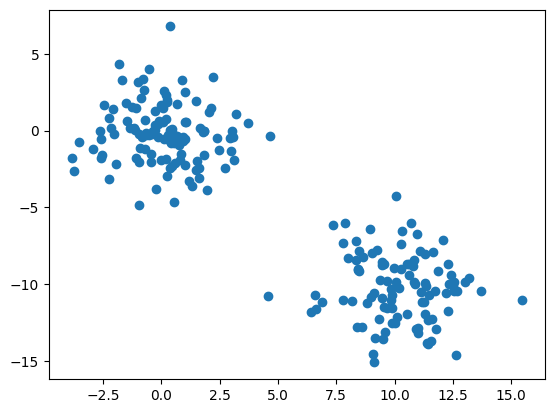

In [37]:
plt.scatter(X0, X1)

Decision boundaries of the SVM and logistic regression can be similar but different. In logistic regression the two big blobs (all data) will influence the boundary the strongest and in SVM the points closer to the separation area (separating hyperplane) will have the biggest influence.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

### **Logistic regression**

In [41]:
# logistic regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Training and test accuracy

In [78]:
acc_train = lr.score(X_train, y_train)
print("Training accuracy for Logistic Regression:", acc_train)

Training accuracy for Logistic Regression: 0.9720670391061452


In [79]:
acc_test = lr.score(X_test, y_test)
print("Test accuracy for Logistic Regression:", acc_test)

Test accuracy for Logistic Regression: 1.0


#### Decision regions

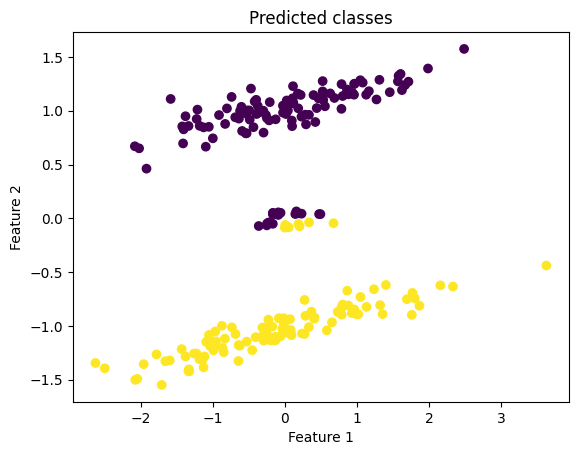

In [64]:
y_pred = lr.predict(X)


plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_pred,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Predicted classes")

plt.show()

The shape has changed because of standardization.

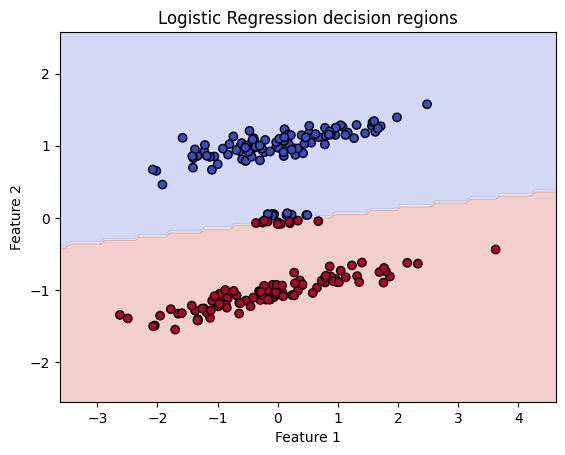

In [65]:
disp = DecisionBoundaryDisplay.from_estimator(
    estimator=lr,
    X=X,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.25,
    xlabel="Feature 1",
    ylabel="Feature 2"
)

disp.ax_.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolor="k"
)

plt.title("Logistic Regression decision regions")
plt.show()

### **SVM**

In [46]:
# svm (linear)
svc = LinearSVC()
svc.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


#### Training and test accuracy

In [80]:
acc_train = svc.score(X_train, y_train)
print("Training accuracy for linear SVM:", acc_train)

Training accuracy for linear SVM: 0.9608938547486033


In [81]:
acc_test = svc.score(X_test, y_test)
print("Test accuracy for linear SVM:", acc_test)

Test accuracy for linear SVM: 0.9555555555555556


#### Decision regions

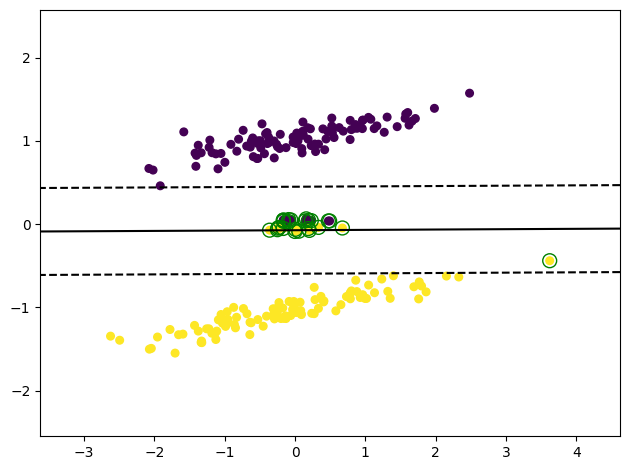

In [ ]:
# support vectors
decision_function = svc.decision_function(X)
support_vector_indices = (np.abs(decision_function) <= 1 + 1e-15).nonzero()[0]
support_vectors = X[support_vector_indices]

# data
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=30,
)

ax = plt.gca()

# hyperplane + margins
DecisionBoundaryDisplay.from_estimator(
    estimator=svc,
    X=X,
    ax=ax,
    plot_method="contour",
    colors="black",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
)

# support vectors
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="green",
)

plt.tight_layout()
plt.show()

#### Comparison 
Logistic regression divided into two classes according to the "shape" of two biggest blobs. It reflects the structure of the large clusters more strongly.<br>
In SVM, it focuses on maximizing the separation margin between the closest points of the two classes.

### **Questions**

**(a) Both methods use linear decision boundaries. Why are the boundaries different?** <br>
The boundaries are different because they optimize different loss functions. Logistic regression minimizes log-loss and is influenced be the oservations while SVM maximizes the margin and depends mainly on the points close to boundary.

**(b) Which observations become support vectors?** <br>
Support vectors become the observations located inside the margin or on the margin. In this dataset they are mainly a small group of points close to the boundary.

**(c) Are support vectors necessarily misclassified observations?** <br>
No, support vectors are not necessarily misclassified observations. They can be correctly classified but lie close to the decision boundary - inside the margin / on the margin.

**(d) Does linear SVM estimate posterior probabilities P(Y = 1 | X= x)?** <br>
No, linear SVM does not estimate posterior probabilities. It returns a decision score for classification by finding the best hyperplane (decision boundary) that separates data into classes with the maximum margin.

**(e) Why does the SVM boundary depend mainly on observations close to the separating boundary, while logistic regression is influenced by all observations?** <br>
SVM uses hinge loss which only cares about data points that are either misclassified or inside the margin.

**(f) How does the SVM boundary depend on the C parameter? ConsiderC ∈ {0.01,0.1,1,10,100}** <br>
**(g) For each value of C, report the number of support vectors.**

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    svc_c = LinearSVC(C=C)
    svc_c.fit(X_train, y_train)

    decision_function = svc_c.decision_function(X)
    support_vector_indices = (np.abs(decision_function) <= 1 + 1e-15).nonzero()[0]

    print(f"C = {C}, number of support vectors = {len(support_vector_indices)}")

C = 0.01, number of support vectors = 224
C = 0.1, number of support vectors = 104
C = 1, number of support vectors = 25
C = 10, number of support vectors = 24
C = 100, number of support vectors = 14


C is a regularization parameter and the strength of regularization is inversly proportional to C, so small C allows for a wider margin while large C tries to classify points more strictly with a narrower margin.